수업 한달 정도 되면서 바이브 코딩도 익숙해지고 대다수 학생들이 문제에 대한 답변은 대충 구할 수 있는 것 같아. 이제 문제는 LLM이 제공한 코드를 그대로 정리하지 않고 사용하면서 이해할 수 없는 코드가 늘어나는게 문제라고 생각해. 그래서 이번 실습은 이제까지 실습을 진행한 코드에서 쓸모없는 부분을 삭제하고 필요한 코드만 남도록 코드 전체를 정리해보려고 해.
데이터 정리는 결국 모델 개발에 사용될 x, y를 정리하는 과정이라고 했는데, 이번 실습에서는 y에 해당되는 정보를 변경하고, 전체 데이터를 다시 정리해볼 예정. 기말에 제출할 최종 보고서 준비 과정을 미리 연습해본다고 생각하면 됨.

실습 파일: 'skin_irritation.xlsx' (NTP ICE에서 다운받은 파일 상태 그대로 사용)

1) label 정의
 (ㄱ) mixture 컬럼: chemical

 (ㄴ) species 컬럼: human

 (ㄷ) endpoint 컬럼의 qualitative classificaiton 결과만 y로 사용. response 컬럼에서 not classified인 경우 label을 0, 그 외 값에 대해서는 1로 설정.

2) 데이터 중복 체크

 (ㄱ) smiles 코드에서 염 제거하고 단일 구조만 저장

 (ㄴ) rdkit을 이용해서 smiles 코드 표준화

 (ㄷ) smiles 코드가 동일한데 label 값이 다른 물질 제거. label 값도 동일하고 smiles 코드도 동일한 경우, 1개만 남기기.

 (ㄹ) 중복 제거된 후 label balance 체크 (label 컬럼 '1' 개수, '0' 개수)
 정확한 개수는 사람마다 조금씩 다를 수 있지만 무슨 목적으로 이렇게 제거했다 써주면 됨.

3) descriptor 계산 후 모델 training

 (ㄱ) rdkit descriptor 계산

 (ㄴ) descriptor 1개만 이용해서 logistic regression 모델 개발

 (ㄷ) 성능이 가장 높은 descriptor를 찾고, 해당 descriptor로 모델 개발했을 때 score 값 확인. (cross validation 사용하지 말고, 전체 데이터에 대해서 훈련을 진행할 것)

* 기말 보고서에서 가장 중요한 부분: 데이터 정리 및 모델 학습 결과를 시각화해서 보여주려면 어떤 그래프를 준비해야 할까?

* 그래프나 표로 데이터 상태, 학습 결과 하나씩 한 번에 보여줘야 함.

* 코드를 말로 설명할 수 있어야 함. 보고서에 그렇게 해야 함.

보고서 제출할 때 지표 여러개 써야 한다.
* scikit-learn

* classification score = accuracy: label 1(positive) 0(negative)를 몇개 맞췄나. 예측이 정확한 데이터 개수/데이터 개수

* sensitivity

* specificity

* confusion matrix: 0인데 0으로/1로 1인데 1로/0으로 맞춘거 비율. 데이터 비율이 안 맞으면 accuracy올리려고 무조건 하나로 할 수도 있음.

이건 0,1로 되어 있으니 regression과는 다른 지표다.

다음달에 모델들에 사기당하지 않으려면 어떻게 하나. 모델을 어떻게 바꿔야 하나.
오버샘플링, 언더샘플링으로 데이터 비율 맞추기. 교수님은 오버샘플링은 별로 안 좋아하지만 방법 찾아서 개선하면 인정.
이 데이터 안 쓴다. qualitative도 같이 보겠다. 0몇개 빼고 비슷한 비율로 만든다.
이것저것 해보고 이래서 실패했으니 이건 안하겠다. 다 해보고 가장 합리적이고 좋아보이는 쪽으로. 합쳐봤는데 그래도 많지 않으니 안되겠다. 다른 시트에 있는걸 합쳐볼까? 이건 수업시간 연습용 할 수 있는 시도를 다 해보자. 성능이 안 좋아도 최선을 다해서 해봤다면. 안 좋은 상황에서 해야할 수 있는 조치를 다 해봤는가.

In [52]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 원본 엑셀 파일 불러오기
df = pd.read_excel('skin_irritation.xlsx', sheet_name=2)

# 1) label 정의
# (ㄱ) mixture 컬럼: chemical, (ㄴ) species 컬럼: human, (ㄷ) endpoint 컬럼의 qualitative classification 결과만 y로 사용
df_filtered = df[
    (df['Mixture'] == 'Chemical') & 
    (df['Species'] == 'Human') & 
    (df['Endpoint'] == 'Qualitative classification')
].copy()

# (ㄷ) response 컬럼에서 not classified인 경우 label을 0, 그 외 값에 대해서는 1로 설정
df_filtered['label'] = df_filtered['Response'].apply(
    lambda x: 0 if str(x).strip().lower() == 'not classified' else 1
)
print("1단계 완료: 데이터 필터링 및 Label 생성")

1단계 완료: 데이터 필터링 및 Label 생성


In [53]:
df_filtered

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Concentration,Concentration_Units,...,Endpoint,Response,Response_Unit,Reference,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS,label
0,skin_irritation_invivo_18,In Vivo,NaN,NaN,Alcohol ethoxylate C12-15/E5 phosphate,NaN,NaN,NaN,NaN,NaN,...,Qualitative classification,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN,0
1,skin_irritation_invivo_83,In Vivo,NaN,NaN,C12-13 beta-branched primary alco hol sulfate,NaN,NaN,NaN,NaN,NaN,...,Qualitative classification,Irritant,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN,1
2,skin_irritation_invivo_80,In Vivo,NaN,NaN,C12-13 beta-branched primary alco hol sulfate/...,NaN,NaN,NaN,NaN,NaN,...,Qualitative classification,Not classified/Possible irritant,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN,1
5,skin_irritation_invivo_55,In Vivo,NaN,NaN,"N,N-Dimethyl-N-dodecyl amino- betaine",NaN,NaN,NaN,NaN,NaN,...,Qualitative classification,Irritant,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,NaN,NaN,NaN,NaN,NaN,1
6,skin_irritation_invivo_48,In Vivo,NaN,NaN,"Bis[(1-Methylimidazol)-(2- ethyl- hexanoate)],...",NaN,NaN,NaN,NaN,NaN,...,Qualitative classification,Not classified,Unitless,Jirova et al. 2010; 20136894; 10.1111/j.1600-0...,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,skin_irritation_invivo_77,In Vivo,NaN,NaN,Triethanolamine,102-71-6,DTXSID9021392,NaN,NaN,NaN,...,Qualitative classification,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,OCCN(CCO)CCO,Triethanolamine,102-71-6|Triethanolamine|2-(bis(2-hydroxyethyl...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9021392,0
1851,skin_irritation_invivo_46,In Vivo,NaN,NaN,Decanoic acid,334-48-5,DTXSID9021554,NaN,NaN,NaN,...,Qualitative classification,Irritant,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,CCCCCCCCCC(O)=O,Decanoic acid,334-48-5|Decanoic acid|1-Nonanecarboxylate|1-N...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9021554,1
1857,skin_irritation_invivo_76,In Vivo,NaN,NaN,Tetradecanol,112-72-1,DTXSID9026926,NaN,NaN,NaN,...,Qualitative classification,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,CCCCCCCCCCCCCCO,1-Tetradecanol,112-72-1|1-Tetradecanol|1-Hydroxytetradecane|1...,https://comptox.epa.gov/dashboard/chemical/det...,NaN,0
1859,skin_irritation_invivo_8,In Vivo,NaN,NaN,Ethylenediamine tetraacetic acid disodium salt,139-33-3,DTXSID9027073,NaN,NaN,NaN,...,Qualitative classification,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,[Na+].[Na+].OC(=O)CN(CCN(CC(O)=O)CC([O-])=O)CC...,"Ethylenediaminetetraacetic acid, disodium salt","139-33-3|Ethylenediaminetetraacetic acid, diso...",https://comptox.epa.gov/dashboard/chemical/det...,NaN,0


In [54]:
from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover

# 2) 데이터 중복 체크 및 정제
remover = SaltRemover() # RDKit의 염(Salt) 제거 사전 불러오기

def get_clean_smi(smi):
    # 불량 구조(| 기호 포함) 및 결측치 제외
    if pd.isna(smi) or '|' in str(smi): 
        return None 
    
    mol = Chem.MolFromSmiles(str(smi))
    if not mol: 
        return None
    
    # (ㄱ) smiles 코드에서 염 제거하고 단일 구조만 저장
    if '.' in str(smi):
        # 1. SaltRemover를 이용해 명백한 염부터 화학적으로 확실히 제거
        stripped_mol = remover.StripMol(mol) 
        stripped_smi = Chem.MolToSmiles(stripped_mol)
        
        # 수산화나트륨([OH-].[Na+])처럼 염 제거 후 전부 날아가 빈칸이 되면 제외
        if not stripped_smi: 
            return None 
        
        # 2. 염 제거 후에도 남은 여러 덩어리 중 가장 긴 구조(Active Ingredient)만 선택
        smi_active = max(stripped_smi.split('.'), key=len)
        mol = Chem.MolFromSmiles(smi_active)
        
    # (ㄴ) rdkit을 이용해서 smiles 코드 표준화
    return Chem.MolToSmiles(mol) if mol else None

# 표준화된 SMILES 컬럼 생성 및 결측치(None) 제거
df_filtered['smi_clean'] = df_filtered['SMILES'].apply(get_clean_smi)
df_filtered = df_filtered.dropna(subset=['smi_clean'])

# (ㄷ) smiles 코드가 동일한데 label 값이 다른 모순된 물질 제거
df_clean = df_filtered.groupby('smi_clean').filter(lambda x: x['label'].nunique() == 1)

# (ㄷ) label 값도 동일하고 smiles 코드도 동일한 경우, 1개만 남기고 중복 제거
df_final = df_clean.drop_duplicates(subset=['smi_clean']).reset_index(drop=True)

# (ㄹ) 중복 제거된 후 label balance 체크 (label 컬럼 '1' 개수, '0' 개수)
print("2단계 완료: [Label Balance 체크]")
print(df_final['label'].value_counts())

2단계 완료: [Label Balance 체크]
label
0    43
1    11
Name: count, dtype: int64


[16:10:16] Explicit valence for atom # 2 B, 5, is greater than permitted


In [55]:
df_final

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Concentration,Concentration_Units,...,Response,Response_Unit,Reference,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS,label,smi_clean
0,skin_irritation_invivo_84,In Vivo,NaN,NaN,Propylene glycol,57-55-6,DTXSID0021206,NaN,NaN,NaN,...,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,CC(O)CO,"1,2-Propylene glycol","57-55-6|1,2-Propylene glycol|(.+-.)-1,2-Propan...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0021206,0,CC(O)CO
1,skin_irritation_invivo_12,In Vivo,NaN,NaN,Heptanal,111-71-7,DTXSID0021597,NaN,NaN,NaN,...,Irritant,Unitless,Jirova et al. 2010; 20136894; 10.1111/j.1600-0...,CCCCCCC=O,Heptanal,111-71-7|Heptanal|1-Heptaldehyde|1-Heptanal|Al...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0021597,1,CCCCCCC=O
2,skin_irritation_invivo_33,In Vivo,NaN,NaN,Isopropyl myristate,110-27-0,DTXSID0026838,NaN,NaN,NaN,...,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,CCCCCCCCCCCCCC(=O)OC(C)C,Isopropyl tetradecanoate,110-27-0|Isopropyl tetradecanoate|1-Methylethy...,https://comptox.epa.gov/dashboard/chemical/det...,NaN,0,CCCCCCCCCCCCCC(=O)OC(C)C
3,skin_irritation_invivo_51,In Vivo,NaN,NaN,4-Methylthio benzaldehyde,3446-89-7,DTXSID0033047,NaN,NaN,NaN,...,Not classified,Unitless,Jirova et al. 2010; 20136894; 10.1111/j.1600-0...,CSC1=CC=C(C=O)C=C1,4-(Methylthio)benzaldehyde,3446-89-7|4-(Methylthio)benzaldehyde|Benzaldeh...,https://comptox.epa.gov/dashboard/chemical/det...,NaN,0,CSc1ccc(C=O)cc1
4,skin_irritation_invivo_15,In Vivo,NaN,NaN,Heptyl butyrate,5870-93-9,DTXSID0042038,NaN,NaN,NaN,...,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,CCCCCCCOC(=O)CCC,Heptyl butyrate,5870-93-9|Heptyl butyrate|BRN 1760253|Butanoic...,https://comptox.epa.gov/dashboard/chemical/det...,NaN,0,CCCCCCCOC(=O)CCC
5,skin_irritation_invivo_27,In Vivo,NaN,NaN,Hydroxycitronellal,89-43-0,DTXSID0044579,NaN,NaN,NaN,...,Not classified,Unitless,Jirova et al. 2010; 20136894; 10.1111/j.1600-0...,COC(=O)C1=C(C=CC=C1)N=CCC(C)CCCC(C)(C)O,"Methyl 2-((7-hydroxy-3,7-dimethyloctylidene)am...","89-43-0|Methyl 2-((7-hydroxy-3,7-dimethyloctyl...",https://comptox.epa.gov/dashboard/chemical/det...,NaN,0,COC(=O)c1ccccc1N=CCC(C)CCCC(C)(C)O
6,skin_irritation_invivo_47,In Vivo,NaN,NaN,Methyl caproate,106-70-7,DTXSID0047616,NaN,NaN,NaN,...,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,CCCCCC(=O)OC,Methyl hexanoate,106-70-7|Methyl hexanoate|BRN 1744683|Caproic ...,https://comptox.epa.gov/dashboard/chemical/det...,NaN,0,CCCCCC(=O)OC
7,skin_irritation_invivo_41,In Vivo,NaN,NaN,1-(2-Isopropylphenyl)-1-phenyle- thane (Mixtur...,191044-60-7,DTXSID00889094,NaN,NaN,NaN,...,Not classified,Unitless,Jirova et al. 2010; 20136894; 10.1111/j.1600-0...,CC(C)C1=CC=CC=C1C(C)C1=CC=CC=C1,"Benzene, 1-(1-methylethyl)-2-(1-phenylethyl)-","191044-60-7|Benzene, 1-(1-methylethyl)-2-(1-ph...",https://comptox.epa.gov/dashboard/chemical/det...,NaN,0,CC(C)c1ccccc1C(C)c1ccccc1
8,skin_irritation_invivo_34,In Vivo,NaN,NaN,Benzyl salicylate,118-58-1,DTXSID1024598,NaN,NaN,NaN,...,Not classified,Unitless,Basketter et al. 2004; 15291823; 10.1111/j.010...,OC1=C(C=CC=C1)C(=O)OCC1=CC=CC=C1,Benzyl salicylate,118-58-1|Benzyl salicylate|204-262-9|4-10-00-0...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID1024598,0,O=C(OCc1ccccc1)c1ccccc1O
9,skin_irritation_invivo_61,In Vivo,NaN,NaN,Sodium dodecyl sulphate,151-21-3,DTXSID1026031,NaN,NaN,NaN,...,Not classified/Possible irritant,Unitless,Robinson et al. 2001; 11422260; 10.1034/j.1600...,[Na+].CCCCCCCCCCCCOS([O-])(=O)=O,Sodium dodecyl sulfate,"151-21-3|Sodium dodecyl sulfate|1-Dodecanol,hy...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID1026031,1,CCCCCCCCCCCCOS(=O)(=O)[O-]


In [56]:
for smi in df_final['smi_clean']:
    print(smi)

CC(O)CO
CCCCCCC=O
CCCCCCCCCCCCCC(=O)OC(C)C
CSc1ccc(C=O)cc1
CCCCCCCOC(=O)CCC
COC(=O)c1ccccc1N=CCC(C)CCCC(C)(C)O
CCCCCC(=O)OC
CC(C)c1ccccc1C(C)c1ccccc1
O=C(OCc1ccccc1)c1ccccc1O
CCCCCCCCCCCCOS(=O)(=O)[O-]
O=C([O-])[O-]
ClCCCCBr
Cl
CCCCCCC(=O)O
CCCCCCCCCCCCCCCC(=O)O
CS(C)=O
CCCSSCCC
NC(CO)(CO)CO
CC(=O)OC(C)(C)C1CC=C(C)CC1
CCCCCCCCC(=O)O
CCCCCCCC(=O)O
CC(C)=CCCC(C)CCO
CCCCCCBr
C=C(C)C(=O)OCCCC
CCCCCCCCCCCCCCCC(=O)OC
CCCCCCOC(=O)c1ccccc1O
OCc1ccccc1
CCCCCCCCCCCC(=O)O
CC1=CCC(C(C)(C)O)CC1
CCCCCCCCCCCC(=O)OC
CCCCCCCCCCCCO
CCCCCCCCCCCCCC(=O)O
CCCCCO
O
CC(C)O
CCCCCCCCO
CCCCCCCCCCO
CC(O)C(=O)O
C=CC(C)(CCC=C(C)C)OC(C)=O
O=C(O)Cc1cccc2ccccc12
CC(O)COC(C)(C)C
CC(C)=CCCC(C)=CCO
C=CCCCCCCCCC(=O)O
CCCCOC(=O)c1ccccc1
COCC(COC)(CC(C)C)C(C)C
C=CCCC(=O)C1=CCCC2(CCCC2)C1
Cc1c[nH]nc1C
CCO
C=CCc1ccc(O)c(OC)c1
OCCN(CCO)CCO
CCCCCCCCCC(=O)O
CCCCCCCCCCCCCCO
O=C([O-])CN(CCN(CC(=O)[O-])CC(=O)O)CC(=O)O
CCCCCCCCCCCCCCCC(=O)OC(C)C


In [57]:
from rdkit.Chem import Descriptors
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 3) descriptor 계산 후 모델 training
# (ㄱ) rdkit descriptor 계산
desc_list = [Descriptors.CalcMolDescriptors(Chem.MolFromSmiles(s)) for s in df_final['smi_clean']]
df_desc = pd.DataFrame(desc_list).dropna(axis=1) # 에러 방지를 위해 결측치 컬럼 즉시 제거
y = df_final['label']

best_score, best_desc = 0, ""
scaler = StandardScaler()

# (ㄴ) descriptor 1개만 이용해서 logistic regression 모델 개발
for col in df_desc.columns:
    X = df_desc[[col]]
    if X[col].nunique() <= 1: continue # 모두 같은 값인 특성은 스케일링 에러가 나므로 건너뜀
    
    X_scaled = scaler.fit_transform(X)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_scaled, y)
    
    # (ㄷ) 성능이 가장 높은 descriptor를 찾고, 해당 descriptor로 모델 개발했을 때 score 값 확인 (전체 데이터 기준)
    score = clf.score(X_scaled, y)
    if score > best_score:
        best_score, best_desc = score, col

print("3단계 완료: [최고 성능 단일 특성 모델 결과]")
print(f"가장 높은 성능을 낸 Descriptor: {best_desc}")
print(f"최고 성능 Score (Accuracy): {best_score*100:.2f}%")

3단계 완료: [최고 성능 단일 특성 모델 결과]
가장 높은 성능을 낸 Descriptor: SlogP_VSA4
최고 성능 Score (Accuracy): 83.33%


In [58]:
# 1. 정제 완료된 SMILES 코드만 추출하여 파일로 저장 (제목, 인덱스 번호 없이 순수 데이터만 저장)
df_final['smi_clean'].to_csv("smiles_for_vega.smi", index=False, header=False)

print("✅ 'smiles_for_vega.smi' 파일이 성공적으로 생성되었습니다!")
print("📌 다음 단계:")
print("1. VEGA 프로그램을 실행합니다.")
print("2. 만들어진 'smiles_for_vega.smi' 파일을 Input으로 넣습니다.")
print("3. 원하는 모델들을 체크하고 계산(Calculate)을 누릅니다.")
print("4. 계산이 끝나면 Export하여 'out.txt'라는 이름으로 현재 폴더에 저장합니다.")

✅ 'smiles_for_vega.smi' 파일이 성공적으로 생성되었습니다!
📌 다음 단계:
1. VEGA 프로그램을 실행합니다.
2. 만들어진 'smiles_for_vega.smi' 파일을 Input으로 넣습니다.
3. 원하는 모델들을 체크하고 계산(Calculate)을 누릅니다.
4. 계산이 끝나면 Export하여 'out.txt'라는 이름으로 현재 폴더에 저장합니다.


In [59]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, MACCSkeys
from rdkit.Chem import rdFingerprintGenerator
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, recall_score, 
                             f1_score, matthews_corrcoef, roc_auc_score)
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. 정답지(y) 및 분자 데이터 준비
# ==========================================
y = df_final['label'].values
smiles_list = df_final['smi_clean'].tolist()
mols = [Chem.MolFromSmiles(smi) for smi in smiles_list]

# ★ 추가된 전체 데이터 정보
total_samples = len(y)
num_class_0 = (y == 0).sum()
num_class_1 = (y == 1).sum()
class_ratio_str = f"0({num_class_0}) : 1({num_class_1})"

print("🔄 Feature 추출 및 모델 학습 진행 중...")

# ==========================================
# 2. Feature 추출 (무한대 에러 해결 버전)
# ==========================================
rdkit_desc = pd.DataFrame([Descriptors.CalcMolDescriptors(m) for m in mols])
x_rdkit = rdkit_desc.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

try:
    vega_desc = pd.read_csv("out.txt", sep='\t')
    vega_desc_numeric = vega_desc.select_dtypes(include=[np.number])
    x_vega_clean = vega_desc_numeric.replace([np.inf, -np.inf], np.nan).dropna(axis=1).reset_index(drop=True)
    x_vega_clean = x_vega_clean.iloc[:len(y)] 
    x_combined = pd.concat([x_rdkit.reset_index(drop=True), x_vega_clean], axis=1)
except Exception as e:
    x_vega_clean = None
    x_combined = None

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
x_morgan = pd.DataFrame([list(morgan_gen.GetFingerprint(m)) for m in mols])

x_maccs = pd.DataFrame([list(MACCSkeys.GenMACCSKeys(m)) for m in mols])

rdkit_gen = rdFingerprintGenerator.GetRDKitFPGenerator()
x_rdkit_fp = pd.DataFrame([list(rdkit_gen.GetFingerprint(m)) for m in mols])

atompair_gen = rdFingerprintGenerator.GetAtomPairGenerator()
x_atompair = pd.DataFrame([list(atompair_gen.GetFingerprint(m)) for m in mols])

torsion_gen = rdFingerprintGenerator.GetTopologicalTorsionGenerator()
x_torsion = pd.DataFrame([list(torsion_gen.GetFingerprint(m)) for m in mols])

# ==========================================
# 3. 특성(Feature)과 모델(Model) 구성
# ==========================================
features_dict = {
    "RDKit_Descriptors": x_rdkit,
    "Morgan_Fingerprint": x_morgan,
    "MACCS_Keys": x_maccs,
    "RDKit_Fingerprint": x_rdkit_fp,
    "AtomPair_Fingerprint": x_atompair,
    "TopologicalTorsion_FP": x_torsion
}

if x_vega_clean is not None:
    features_dict["VEGA_Descriptors"] = x_vega_clean
    features_dict["Combined_RDKit_VEGA"] = x_combined

models_dict = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42)
}

# ==========================================
# 4. 모델 훈련 및 요청하신 평가지표 계산
# ==========================================
results = []
scaler = StandardScaler()

for feature_name, X_data in features_dict.items():
    if X_data is None or X_data.empty:
        continue
        
    X_scaled = scaler.fit_transform(X_data)
    num_features = X_data.shape[1] # ★ (행, 열) 중 특성의 개수인 '열' 숫자만 가져옴
    
    for model_name, model in models_dict.items():
        try:
            if model_name == "HistGradientBoosting":
                model.fit(X_data, y)
                y_pred = model.predict(X_data)
                y_prob = model.predict_proba(X_data)[:, 1]
            else:
                model.fit(X_scaled, y)
                y_pred = model.predict(X_scaled)
                y_prob = model.predict_proba(X_scaled)[:, 1]
            
            cm = confusion_matrix(y, y_pred)
            tn, fp, fn, tp = cm.ravel()
            
            confusion_matrix_str = f"TP:{tp} TN:{tn} FP:{fp} FN:{fn}" 
            accuracy = accuracy_score(y, y_pred)
            sensitivity = recall_score(y, y_pred) 
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            recall = recall_score(y, y_pred) 
            f1_score_val = f1_score(y, y_pred)
            matthews_correlation_coefficient = matthews_corrcoef(y, y_pred)
            roc_auc = roc_auc_score(y, y_prob)
            
            # 최종 테이블 데이터 적재
            results.append({
                "Feature": feature_name,
                "Model": model_name,
                "N_samples": total_samples,           # ★ 추가: 학습 데이터 수
                "Class_Ratio": class_ratio_str,       # ★ 추가: 0과 1의 불균형 비율
                "N_Features": num_features,           # ★ 추가: 사용된 변수의 개수
                "confusion matrix": confusion_matrix_str,
                "accuracy": round(accuracy, 4),
                "sensitivity": round(sensitivity, 4),
                "specificity": round(specificity, 4),
                "recall": round(recall, 4),
                "f1-score": round(f1_score_val, 4),
                "matthew's correlation coefficient": round(matthews_correlation_coefficient, 4),
                "roc auc": round(roc_auc, 4)
            })
            
        except Exception as e:
            print(f"⚠️ {feature_name} - {model_name} 훈련 중 에러: {e}")

# ==========================================
# 5. 최종 결과 출력
# ==========================================
results_df = pd.DataFrame(results)

# 가장 성능이 좋은 순서대로 정렬 (accuracy와 sensitivity 기준)
results_df = results_df.sort_values(by=['accuracy', 'sensitivity'], ascending=[False, False]).reset_index(drop=True)

print("🏆 [분류 모델 평가 지표 결과 테이블]")
display(results_df)

🔄 Feature 추출 및 모델 학습 진행 중...
🏆 [분류 모델 평가 지표 결과 테이블]


,Feature,Model,N_samples,Class_Ratio,N_Features,confusion matrix,accuracy,sensitivity,specificity,recall,f1-score,matthew's correlation coefficient,roc auc
0,RDKit_Descriptors,Logistic Regression,54,0(43) : 1(11),217,TP:11 TN:43 FP:0 FN:0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,AtomPair_Fingerprint,Logistic Regression,54,0(43) : 1(11),2048,TP:11 TN:43 FP:0 FN:0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,VEGA_Descriptors,Logistic Regression,54,0(43) : 1(11),1894,TP:11 TN:43 FP:0 FN:0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,VEGA_Descriptors,HistGradientBoosting,54,0(43) : 1(11),1894,TP:11 TN:43 FP:0 FN:0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,Combined_RDKit_VEGA,Logistic Regression,54,0(43) : 1(11),2111,TP:11 TN:43 FP:0 FN:0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,Combined_RDKit_VEGA,HistGradientBoosting,54,0(43) : 1(11),2111,TP:11 TN:43 FP:0 FN:0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,RDKit_Descriptors,HistGradientBoosting,54,0(43) : 1(11),217,TP:10 TN:43 FP:0 FN:1,0.9815,0.9091,1.0000,0.9091,0.9524,0.9426,1.0000
7,TopologicalTorsion_FP,Logistic Regression,54,0(43) : 1(11),2048,TP:10 TN:42 FP:1 FN:1,0.9630,0.9091,0.9767,0.9091,0.9091,0.8858,0.9905
8,Morgan_Fingerprint,Logistic Regression,54,0(43) : 1(11),2048,TP:11 TN:40 FP:3 FN:0,0.9444,1.0000,0.9302,1.0000,0.8800,0.8549,0.9873
9,MACCS_Keys,Logistic Regression,54,0(43) : 1(11),167,TP:11 TN:40 FP:3 FN:0,0.9444,1.0000,0.9302,1.0000,0.8800,0.8549,0.9873


In [60]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, recall_score, 
                             f1_score, matthews_corrcoef, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

# 1. 정답지(y) 준비 (이전 단계의 df_final 사용)
y = df_final['label'].values

# ==========================================
# 2. 모든 Feature 그룹에 대한 단일 변수 모델 훈련 루프
# ==========================================
print("🔄 모든 특성 그룹(RDKit, VEGA, 핑거프린트 등)의 변수를 1개씩 분리하여 모델을 평가합니다...")
print("이 작업은 변수가 많아 수 초 ~ 수십 초 정도 소요될 수 있습니다.\n")

results_single_all = []

# features_dict는 이전에 만든 8개 그룹(RDKit, Morgan, AtomPair, VEGA 등)을 담고 있는 딕셔너리입니다.
for feature_group_name, X_data in features_dict.items():
    if X_data is None or X_data.empty:
        continue
        
    # 무한대 및 결측치 제거하여 안전한 데이터로 정제
    X_clean = X_data.replace([np.inf, -np.inf], np.nan).dropna(axis=1).reset_index(drop=True)
    
    # 해당 그룹의 모든 열(단일 Descriptor 또는 단일 Bit)을 하나씩 순회
    for col in X_clean.columns:
        x_single = X_clean[col].values.reshape(-1, 1)
        
        # [데이터 필터링] 모든 분자가 동일한 값(예: 모두 0)을 가지면 학습의 의미가 없으므로 제외
        if len(np.unique(x_single)) <= 1:
            continue
            
        try:
            # 단일 변수 스케일링
            scaler = StandardScaler()
            x_scaled = scaler.fit_transform(x_single)
            
            # 모델 훈련
            clf = LogisticRegression(random_state=42)
            clf.fit(x_scaled, y)
            
            # 예측값 및 확률값 추출
            y_pred = clf.predict(x_scaled)
            y_prob = clf.predict_proba(x_scaled)[:, 1]
            
            # 평가지표 계산
            cm = confusion_matrix(y, y_pred)
            if cm.shape == (2, 2):
                tn, fp, fn, tp = cm.ravel()
            else:
                continue # 정상적인 분할이 안 된 경우는 스킵
                
            acc = accuracy_score(y, y_pred)
            sens = recall_score(y, y_pred) 
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0
            f1 = f1_score(y, y_pred)
            mcc = matthews_corrcoef(y, y_pred)
            roc_auc = roc_auc_score(y, y_prob)
            
            # 결과 저장
            results_single_all.append({
                "Feature_Group": feature_group_name,     # 어떤 특성 그룹에서 왔는지 (예: AtomPair)
                "Descriptor_or_Bit": col,                # 디스크립터 이름 또는 Bit 번호
                "confusion matrix": f"TP:{tp} TN:{tn} FP:{fp} FN:{fn}",
                "accuracy": round(acc, 4),
                "sensitivity": round(sens, 4),
                "specificity": round(spec, 4),
                "recall": round(sens, 4),
                "f1-score": round(f1, 4),
                "matthew's correlation coefficient": round(mcc, 4),
                "roc auc": round(roc_auc, 4)
            })
            
        except Exception:
            continue # 예외 발생 시 다음 변수로 넘어감

# ==========================================
# 3. 최종 결과 정렬 및 출력
# ==========================================
df_single_all_results = pd.DataFrame(results_single_all)

# 정확도(Accuracy), 민감도(Sensitivity), ROC AUC 순으로 내림차순 정렬
df_single_all_results = df_single_all_results.sort_values(
    by=['accuracy', 'sensitivity', 'roc auc'], 
    ascending=[False, False, False]
).reset_index(drop=True)

print("🏆 [모든 Feature 기반 단일 변수(1 Descriptor/Bit) 분류 성능 TOP 20]")
display(df_single_all_results.head(20))

🔄 모든 특성 그룹(RDKit, VEGA, 핑거프린트 등)의 변수를 1개씩 분리하여 모델을 평가합니다...
이 작업은 변수가 많아 수 초 ~ 수십 초 정도 소요될 수 있습니다.

🏆 [모든 Feature 기반 단일 변수(1 Descriptor/Bit) 분류 성능 TOP 20]


,Feature_Group,Descriptor_or_Bit,confusion matrix,accuracy,sensitivity,specificity,recall,f1-score,matthew's correlation coefficient,roc auc
0,MACCS_Keys,124,TP:3 TN:42 FP:1 FN:8,0.8333,0.2727,0.9767,0.2727,0.4000,0.3837,0.6247
1,VEGA_Descriptors,BEH6p,TP:2 TN:43 FP:0 FN:9,0.8333,0.1818,1.0000,0.1818,0.3077,0.3877,0.7368
2,Combined_RDKit_VEGA,BEH6p,TP:2 TN:43 FP:0 FN:9,0.8333,0.1818,1.0000,0.1818,0.3077,0.3877,0.7368
3,VEGA_Descriptors,BEH6v,TP:2 TN:43 FP:0 FN:9,0.8333,0.1818,1.0000,0.1818,0.3077,0.3877,0.7357
4,Combined_RDKit_VEGA,BEH6v,TP:2 TN:43 FP:0 FN:9,0.8333,0.1818,1.0000,0.1818,0.3077,0.3877,0.7357
5,VEGA_Descriptors,BEL7v,TP:2 TN:43 FP:0 FN:9,0.8333,0.1818,1.0000,0.1818,0.3077,0.3877,0.6977
6,Combined_RDKit_VEGA,BEL7v,TP:2 TN:43 FP:0 FN:9,0.8333,0.1818,1.0000,0.1818,0.3077,0.3877,0.6977
7,VEGA_Descriptors,BEL7p,TP:2 TN:43 FP:0 FN:9,0.8333,0.1818,1.0000,0.1818,0.3077,0.3877,0.6956
8,Combined_RDKit_VEGA,BEL7p,TP:2 TN:43 FP:0 FN:9,0.8333,0.1818,1.0000,0.1818,0.3077,0.3877,0.6956
9,VEGA_Descriptors,BEL7m,TP:2 TN:43 FP:0 FN:9,0.8333,0.1818,1.0000,0.1818,0.3077,0.3877,0.6765


사회에 나가면 정답이 없는 문제를 해결해야 돼. 그래서 내가 제시한 답을 정답으로 만들기 위한 근거와 설득 자료를 만드는 능력이 중요해. 그래서 기말고사 문제는 굉장히 자유도가 높게 출제될 예정이야.

기말 문제: NTP ICE에 있는 데이터를 이용해서 독성 예측 모델을 개발하고, 개발 과정을 보고서로 정리해서 제출. (제출 자료: 보고서 & 개발 과정이 정리된 jupyter notebook 과 코드 실행에 필요한 데이터)

그래서 수업시간에 답을 알려주는 것이 아니라, 코드를 작성한 이유를 설명해주려고 해. 모든 의사 결정에는 장단점이 있기 때문에, 의사결정에서 발생할 수 있는 장점과 단점을 고려해서 왜 내 선택이 합당한지를 설명할 수 있어야 해.  

+무슨 모델을 어떻게 만들지 정해야 한다. 데이터 상태 안 좋은데 쓸지 말지 정하고 잘 써야 함. 이유같은거 잘 안쓰면 데이터가 많든 적든 감점. human 데이터 적지만 그게 의미 있으니 쓰겠다. 적을 때 해야 하는 것들(balance 맞추기)이 이런게 있고 이렇게 했다.
이런 논리를 가지고 이런 이유로 이렇게 만들었다 서술해야 한다.
+코드 최대한 단순하게 써라. 코드에 대한 설명을 주석으로 잘 써라. 단순한 코드가 아닌데 주석이 없거나 llm이 쓴 형식이라면 이해할 수 없는 범위를 쓴 것으로 간주하고 감점하겠다.
+descriptor 많을수록 끼워맞추기 쉬워져서 학습한 데이터에 대해서는 잘 맞추지만 학습하지 않은건 잘 못 맞추게 될 수 있다. 개수 조절이 필요하다. 원래 비율 5:1. 데이터 5개당 디스크립터 하나. 무슨 조합을? 나중에 feature selection 모델 따로 할 예정. 지금은 일단 하나만 해보고 조금씩늘리려고 하나씩만 해보라고 한거다. 다 한사람은 디스크립터 늘려봐도 된다.

실습 파일: 'skin_irritation.xlsx' (NTP ICE에서 다운받은 파일 상태 그대로 사용)

1) endpoint 선택
 (ㄱ) mixture 컬럼: chemical

 (ㄴ) species 컬럼: human

 (ㄷ) endpoint 컬럼의 positive reaction 결과만 y로 사용. linear regression 모델을 개발할 예정이므로, 연속된 수치 값을 사용.

2) 데이터 중복 체크

 (ㄱ) smiles 코드에서 염 제거하고 단일 구조만 저장

 (ㄴ) rdkit을 이용해서 smiles 코드 표준화

 (ㄷ) smiles 코드가 동일한데 positive reaction 값이 다른 물질 확인. 값 차이가 크지 않다면 평균 값 사용. 값 차이가 크다면 제외. (값 차이가 크다 작다의 기준은 스스로 만들어볼 것)

 (ㄹ) 중복 제거된 후 positive reaction 분포 체크 (histogram)

3) descriptor 계산 후 모델 training

 (ㄱ) rdkit descriptor 계산

 (ㄴ) descriptor 1개만 이용해서 linear regression 모델 개발

 (ㄷ) 성능이 가장 높은 descriptor를 찾고, 해당 descriptor로 모델 개발했을 때 score 값 확인. (cross validation 사용하지 말고, 전체 데이터에 대해서 훈련을 진행할 것)

* 모델 검증 지표를 다양하게 사용해서 모델 성능을 평가할 것.

regression 모델: R2, RMSE (root mean squared error), MAE (mean absolute error), normalized RMSE, spearmann's correlation

classification 모델: confusion matrix, accuracy, senstivitiy, specificity, recall, f1-score, matthew's correlation coefficient, roc auc

R2 0.6만 나와도 잘나왔다. 지금 0이 많아서 잘 안된다. 데이터 범위가 0~100인데 벗어나는 값이 나올 때도 있다. 예측을 한 다음에 0보다 작으면 0으로 100보다 크면 100으로 맞추기도 한다.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.SaltRemover import SaltRemover
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr
import warnings

warnings.filterwarnings('ignore')

# ==============================================================================
# 1) Endpoint 선택
# ==============================================================================
# 원본 NTP ICE 엑셀 파일 로드
df = pd.read_excel('skin_irritation.xlsx',sheet_name=2)

# (ㄱ), (ㄴ), (ㄷ) 조건 필터링
# [의사결정 논리] 동물 데이터보다 인체 반응을 더 정확히 대변하는 human 데이터를 선택함.
# 또한 'positive reaction'은 범주형이 아닌 연속된 백분율(%) 수치이므로, 이를 통해 물질의 자극성을 정량적인 선형 회귀(Linear Regression) 모델로 예측하고자 함.
df_filtered = df[(df['Mixture'] == 'Chemical') & 
                 (df['Species'] == 'Human') & 
                 (df['Endpoint'] == 'Positive reaction')].copy()

# Linear Regression에 사용할 연속형 수치를 위해 Response 값을 숫자로 변환 (변환 불가한 값은 NaN 처리 후 제거)
df_filtered['Response'] = pd.to_numeric(df_filtered['Response'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['SMILES', 'Response'])


[16:11:12] Explicit valence for atom # 2 B, 5, is greater than permitted


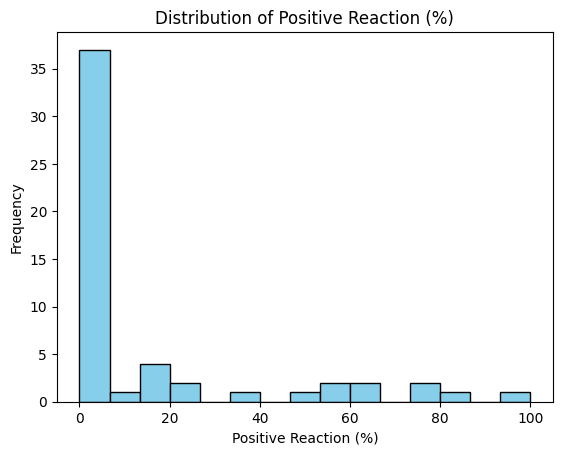

In [62]:
# ==============================================================================
# 2) 데이터 중복 체크 및 정제
# ==============================================================================
# 구조가 명확하지 않은 혼합물(| 포함) 1차 제외
df_clean_smi = df_filtered.loc[~df_filtered['SMILES'].str.contains('|', regex=False)].copy()

# (ㄱ), (ㄴ) SMILES 코드 염 제거 및 표준화
remover = SaltRemover()

for index, row in df_clean_smi.iterrows():
    smi = row['SMILES']
    mol = Chem.MolFromSmiles(str(smi))
    
    if mol is not None:
        if '.' in str(smi):
            stripped_mol = remover.StripMol(mol) # salt 제거
            stripped_smi = Chem.MolToSmiles(stripped_mol)
            smi_list = stripped_smi.split('.')
            
            # 가장 큰 분자를 active ingredient로 추출
            smi_active = ''
            for each_smi in smi_list:
                if len(each_smi) > len(smi_active):
                    smi_active = each_smi
            smi_without_salt = smi_active
        else:
            smi_without_salt = str(smi)
            
        # (ㄴ) RDKit을 이용해 smiles 코드 표준화
        standard_mol = Chem.MolFromSmiles(smi_without_salt)
        if standard_mol is not None:
            smi_standard = Chem.MolToSmiles(standard_mol)
            df_clean_smi.loc[index, 'standardized_smi'] = smi_standard

df_clean_smi = df_clean_smi.dropna(subset=['standardized_smi'])

# (ㄷ) 동일한 SMILES인데 positive reaction 값이 다른 물질 확인 및 처리
# [의사결정 기준: 10% 차이] 
# Human patch test의 특성상 사람마다 피부 민감도가 달라 실험 오차가 발생할 수 있음.
# 따라서 동일 물질의 실험 결과 차이(max - min)가 10% 이내라면 자연적인 실험 오차로 간주하여 '평균(mean)'을 취해 귀중한 human 데이터를 보존함.
# 만약 차이가 10%를 초과한다면 실험 자체의 결함이거나 모순이 크다고 판단하여 모델의 혼란을 막기 위해 제외함.
grouped = df_clean_smi.groupby('standardized_smi')['Response'].agg(['max', 'min', 'mean']).reset_index()
grouped['diff'] = grouped['max'] - grouped['min']

valid_data = grouped[grouped['diff'] <= 10].copy() # 10% 이하 차이만 살림
valid_data = valid_data[['standardized_smi', 'mean']]
valid_data.rename(columns={'mean': 'positive_reaction'}, inplace=True)

# (ㄹ) 중복 제거된 후 positive reaction 분포 체크 (히스토그램)
plt.hist(valid_data['positive_reaction'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribution of Positive Reaction (%)')
plt.xlabel('Positive Reaction (%)')
plt.ylabel('Frequency')
plt.show()


In [63]:
valid_data

,standardized_smi,positive_reaction
0,,59.40
1,C=C(C)C(=O)OCCCC,0.00
2,C=CC(C)(CCC=C(C)C)OC(C)=O,1.60
3,C=CCCC(=O)C1=CCCC2(CCCC2)C1,0.00
4,C=CCCCCCCCCC(=O)O,3.50
5,C=CCc1ccc(O)c(OC)c1,15.30
7,CC(=O)OC(C)(C)C1CC=C(C)CC1,0.00
8,CC(C)=CCCC(C)=CCO,17.90
9,CC(C)=CCCC(C)CCO,0.00
10,CC(C)O,0.00


In [64]:
# ==============================================================================
# 3) Descriptor 계산 후 모델 Training
# ==============================================================================
# (ㄱ) RDKit descriptor 계산
desc_total = []
valid_smiles = []
y_values = []

for index, row in valid_data.iterrows():
    smi = row['standardized_smi']
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        desc = Descriptors.CalcMolDescriptors(mol)
        desc_total.append(desc)
        y_values.append(row['positive_reaction'])

df_desc = pd.DataFrame(desc_total)
y = np.array(y_values)

# [의사결정 논리] 데이터 개수(N수)가 적으므로 행을 버리면 안 됨. 
# 계산 실패한 무한대(inf)나 결측치(NaN)를 발생시킨 불안정한 Feature(열)를 통째로 삭제함.
df_desc = df_desc.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

# (ㄴ), (ㄷ) 1개 Descriptor만 이용한 모델 개발 및 성능 탐색
# [의사결정 논리] Human 데이터는 개수가 매우 적음. 여기에 수십~수백 개의 Descriptor를 넣으면 무조건 과적합(Overfitting) 발생.
# 따라서 물질의 특성을 가장 잘 설명하는 단일(1개) Descriptor만 사용하여, 단순하고 직관적인 Linear Regression 모델을 개발하는 것이 합당함.
best_score = -float('inf')
best_desc_name = ""
best_model = None

print("🔍 최적의 단일 Descriptor 탐색 중...")
for col in df_desc.columns:
    # 모델 학습을 위해 x를 2차원 배열로 변환
    x_single = df_desc[col].values.reshape(-1, 1) 
    
    # Cross validation 없이 전체 데이터에 대해 훈련
    model = LinearRegression()
    model.fit(x_single, y)
    score = model.score(x_single, y) # 기본 score는 R2 
    
    if score > best_score:
        best_score = score
        best_desc_name = col
        best_model = model

print(f"🏆 가장 성능이 높은 Descriptor: {best_desc_name}")
print(f"📈 최고 R2 Score (Train 전체 기준): {best_score:.4f}")

🔍 최적의 단일 Descriptor 탐색 중...
🏆 가장 성능이 높은 Descriptor: EState_VSA2
📈 최고 R2 Score (Train 전체 기준): 0.1450


In [65]:
# ==============================================================================
# 4) 모델 검증 지표 시각화 (Regression 모델 지표 적용)
# ==============================================================================
# 예측값 생성
x_best = df_desc[best_desc_name].values.reshape(-1, 1)
y_pred = best_model.predict(x_best)

# 요구된 지표 계산
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

# Normalized RMSE (최대값 - 최소값 범위로 오차를 스케일링)
y_range = np.max(y) - np.min(y)
nrmse = (rmse / y_range) if y_range != 0 else 0 

# Spearman's correlation (예측값과 실제값의 순위 상관계수. 1번째 값이 상관계수, 2번째 값이 p-value)
spearman_corr, _ = spearmanr(y, y_pred)

print("\n📊 [최종 Linear Regression 모델 평가 지표]")
print("-" * 50)
print(f"1. R2 Score             : {r2:.4f} (1에 가까울수록 모델 설명력 우수)")
print(f"2. RMSE                 : {rmse:.4f}")
print(f"3. MAE                  : {mae:.4f}")
print(f"4. Normalized RMSE      : {nrmse:.4f}")
print(f"5. Spearman Correlation : {spearman_corr:.4f} (1에 가까울수록 순위 일치도 높음)")
print("-" * 50)


📊 [최종 Linear Regression 모델 평가 지표]
--------------------------------------------------
1. R2 Score             : 0.1450 (1에 가까울수록 모델 설명력 우수)
2. RMSE                 : 24.2066
3. MAE                  : 18.6015
4. Normalized RMSE      : 0.2421
5. Spearman Correlation : 0.3398 (1에 가까울수록 순위 일치도 높음)
--------------------------------------------------


In [68]:
df_final.columns

Index(['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name',
       'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient',
       'Concentration', 'Concentration_Units', 'Mixture', 'Species',
       'Reported_Strain', 'Strain', 'Sex', 'Assay', 'Endpoint', 'Response',
       'Response_Unit', 'Reference', 'SMILES', 'Preferred_Name', 'Synonyms',
       'URL_CompTox', 'URL_CEBS', 'label', 'smi_clean'],
      dtype='str')

In [66]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# 1. 정답지(y) 준비: 연속형 수치인 positive reaction (%)
y = df_final['Positive_reaction'].values
y_range = np.max(y) - np.min(y) # Normalized RMSE 계산용 분모

# ==========================================
# 2. 모든 Feature 그룹에 대한 단일 변수 모델 훈련 루프 (Linear Regression)
# ==========================================
print("🔄 모든 특성 그룹의 변수를 1개씩 분리하여 선형 회귀(Linear Regression) 모델을 평가합니다...")
print("이 작업은 수 초 ~ 수십 초 정도 소요될 수 있습니다.\n")

results_single_linear = []

for feature_group_name, X_data in features_dict.items():
    if X_data is None or X_data.empty:
        continue
        
    # 무한대 및 결측치 제거
    X_clean = X_data.replace([np.inf, -np.inf], np.nan).dropna(axis=1).reset_index(drop=True)
    
    for col in X_clean.columns:
        x_single = X_clean[col].values.reshape(-1, 1)
        
        # 모든 값이 동일한(변별력이 없는) Feature는 제외
        if len(np.unique(x_single)) <= 1:
            continue
            
        try:
            # 단일 변수 스케일링
            scaler = StandardScaler()
            x_scaled = scaler.fit_transform(x_single)
            
            # 선형 회귀 모델 훈련
            lr_model = LinearRegression()
            lr_model.fit(x_scaled, y)
            
            # 예측값 생성
            y_pred = lr_model.predict(x_scaled)
            
            # 교수님이 요구하신 평가지표 계산
            r2 = r2_score(y, y_pred)
            rmse = np.sqrt(mean_squared_error(y, y_pred))
            mae = mean_absolute_error(y, y_pred)
            nrmse = (rmse / y_range) if y_range != 0 else 0
            spearman_corr, _ = spearmanr(y, y_pred)
            
            # 결과 저장
            results_single_linear.append({
                "Feature_Group": feature_group_name,
                "Descriptor_or_Bit": col,
                "R2_Score": round(r2, 4),
                "RMSE": round(rmse, 4),
                "MAE": round(mae, 4),
                "Normalized_RMSE": round(nrmse, 4),
                "Spearman_Correlation": round(spearman_corr, 4)
            })
            
        except Exception:
            continue

# ==========================================
# 3. 최종 결과 정렬 및 출력
# ==========================================
df_single_linear_results = pd.DataFrame(results_single_linear)

# 모델의 설명력을 나타내는 R2_Score가 높은 순서대로 정렬 (R2가 같으면 오차인 RMSE가 작은 순)
df_single_linear_results = df_single_linear_results.sort_values(
    by=['R2_Score', 'RMSE'], 
    ascending=[False, True]
).reset_index(drop=True)

print("🏆 [모든 Feature 기반 단일 변수(1 Descriptor) 선형 회귀 성능 TOP 20]")
display(df_single_linear_results.head(20))

KeyError: 'positive_reaction'